# Import Required Libraries

Import libraries for data analysis, including pandas, numpy, matplotlib, seaborn, and statsmodels for VIF.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Set Korean font if needed
plt.rcParams['font.family'] = 'Malgun Gothic'  # For Windows

statsmodels not available. VIF calculation will be skipped.


## Load Data

Load the RBI dataset from the CSV file.

In [4]:
df = pd.read_csv('output/자치구 단위 RBI.csv')
print(df.head())

   자치구     인구수  안전센터수  출동건수  화재사고건수  교통사고건수         센터당_인구      센터당_화재  \
0  종로구  142309      6  6291    1639     219   23718.166667  273.166667   
1   중구  126445      5  4455    1319     149   25289.000000  263.800000   
2  용산구  200695      5  6849    1415     336   40139.000000  283.000000   
3  성동구  271512      4  4903    1454     285   67878.000000  363.500000   
4  광진구  338541      3  6983    1815     267  112847.000000  605.000000   

        센터당_출동    인구10만당_화재    인구10만당_출동   인구10만당_교통     LQ_화재     LQ_구조  
0  1048.500000  1151.719146  4420.662080  153.890478  1.863907  1.933680  
1   891.000000  1043.141287  3523.270987  117.837795  1.688188  1.541144  
2  1369.800000   705.049951  3412.641072  167.418222  1.141031  1.492753  
3  1225.750000   535.519609  1805.813371  104.967736  0.866669  0.789896  
4  2327.666667   536.124133  2062.674831   78.867848  0.867647  0.902252  


## Correlation Analysis

Analyze correlations between numeric indicators to identify relationships.

c:\Users\DH\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
c:\Users\DH\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


c:\Users\DH\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
c:\Users\DH\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


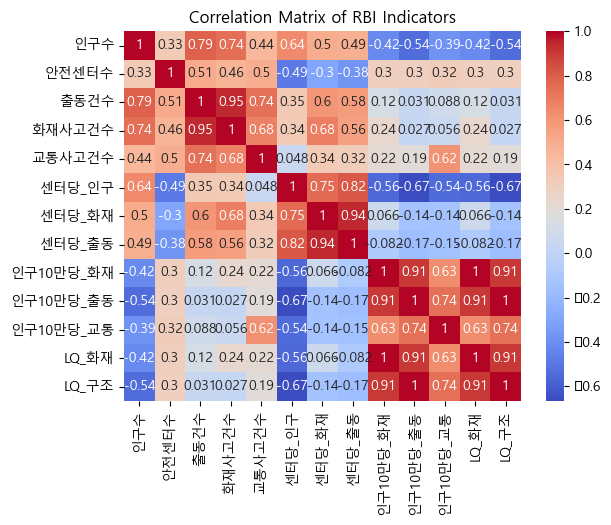

In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of RBI Indicators')
plt.show()

## Multicollinearity Check (VIF)

Check for multicollinearity using Variance Inflation Factor (VIF).

In [6]:
def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df["Variable"] = data.columns
    vif_df["VIF"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df

vif_data = calculate_vif(df[numeric_cols])
print(vif_data)

statsmodels not available. Skipping VIF calculation.


## Weight Design and RBI Calculation

Design weights and calculate the Response Burden Index (RBI).

In [7]:
# Select key indicators for RBI
indicator_cols = ['센터당_인구', '센터당_화재', '센터당_출동', '인구10만당_화재', 'LQ_화재']

# Simple equal weights
weights = {col: 1/len(indicator_cols) for col in indicator_cols}
print("Weights:", weights)

# Normalize indicators (min-max scaling)
df_norm = df.copy()
for col in indicator_cols:
    df_norm[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

# Calculate RBI
df_norm['RBI'] = sum(df_norm[col] * weights[col] for col in indicator_cols)
print(df_norm[['자치구', 'RBI']].head())

Weights: {'센터당_인구': 0.2, '센터당_화재': 0.2, '센터당_출동': 0.2, '인구10만당_화재': 0.2, 'LQ_화재': 0.2}
   자치구       RBI
0  종로구  0.418447
1   중구  0.348994
2  용산구  0.263707
3  성동구  0.250618
4  광진구  0.534444


## Ranking and Visualization

Rank districts by RBI and visualize the top vulnerable areas.

Top 5 취약 지역:
    자치구       RBI
22  강남구  0.793792
17  금천구  0.770708
20  관악구  0.706124
11  은평구  0.630128
23  송파구  0.570834


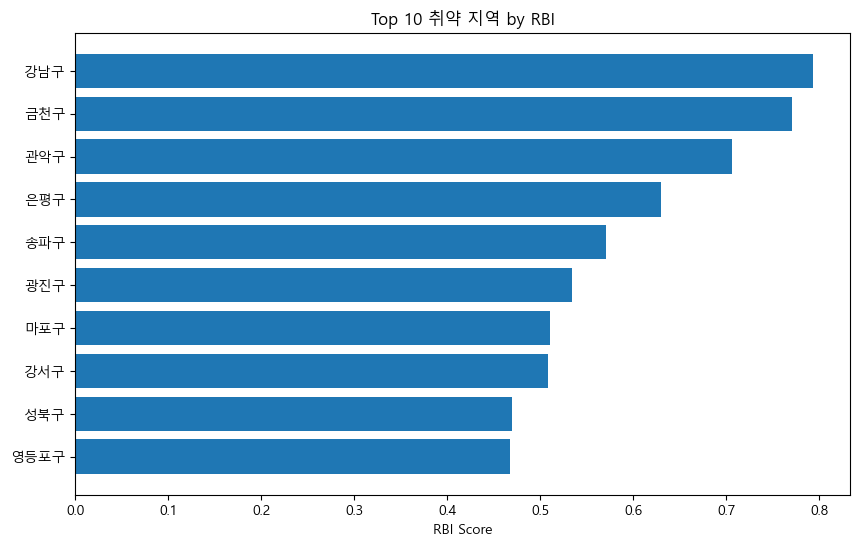

In [8]:
df_sorted = df_norm.sort_values('RBI', ascending=False)
print("Top 5 취약 지역:")
print(df_sorted[['자치구', 'RBI']].head())

plt.figure(figsize=(10, 6))
plt.barh(df_sorted['자치구'][:10], df_sorted['RBI'][:10])
plt.xlabel('RBI Score')
plt.title('Top 10 취약 지역 by RBI')
plt.gca().invert_yaxis()
plt.show()